# Geração dos dados: descrição matemática

Seja um conjunto fixo de pontos de entrada

$$
x = (x_1, x_2, \dots, x_n), \qquad x_i \in \mathbb{R}.
$$

---

## 1. Dataset não correlacionado (ruído i.i.d.)

Cada observação é gerada de forma independente:

$$
y_i \sim \mathcal N(0, \sigma^2), \qquad i = 1,\dots,n.
$$

Em forma vetorial:

$$
\mathbf y \sim \mathcal N(\mathbf 0, \sigma^2 I).
$$

Aqui:
- $I$ é a matriz identidade
- não há correlação entre observações
- a incerteza é puramente local (covariância diagonal)

---

## 2. Dataset correlacionado (Processo Gaussiano)

### 2.1 Kernel (estrutura de correlação)

A correlação entre os dados é especificada por um kernel SE/RBF:

$$
k(x_i, x_j)
=
\sigma_f^2
\exp\!\left(
-\frac{(x_i - x_j)^2}{2\ell^2}
\right),
$$

onde:
- $\sigma_f^2$ controla a amplitude do processo
- $\ell$ controla o comprimento de correlação

A matriz de covariância do sinal é:

$$
K_{ij} = k(x_i, x_j).
$$

---

### 2.2 Ruído independente de medição

Assumimos também um ruído i.i.d. associado às observações:

$$
\boldsymbol\eta \sim \mathcal N(\mathbf 0, \sigma_n^2 I).
$$

---

### 2.3 Covariância total dos dados observados

A covariância do vetor observado $\mathbf y$ é:

$$
\mathrm{Cov}(\mathbf y)
=
K + \sigma_n^2 I
\;\equiv\;
K_y.
$$

Isso separa claramente:
- estrutura correlacionada: $K$
- incerteza local: $\sigma_n^2 I$

---

## 3. Amostragem via decomposição de Cholesky

Como $K_y$ é simétrica e definida positiva, ela admite uma decomposição de Cholesky:

$$
K_y = L L^\top,
$$

onde $L$ é triangular inferior.

---

### 3.1 Fonte de aleatoriedade

Geramos um vetor de variáveis independentes:

$$
\boldsymbol\epsilon \sim \mathcal N(\mathbf 0, I).
$$

---

### 3.2 Geração do dado correlacionado

Definimos:

$$
\mathbf y = L \boldsymbol\epsilon.
$$

Então:

$$
\mathbb E[\mathbf y] = \mathbf 0,
\qquad
\mathrm{Cov}(\mathbf y) = L I L^\top = K_y.
$$

---

## 4. Interpretação conceitual

- A aleatoriedade fundamental vem de $\boldsymbol\epsilon$
- A correlação entre os dados é induzida pela transformação linear $L$
- O kernel define a geometria da incerteza
- O termo diagonal representa incerteza local não estruturada

Em palavras:

> **Os dados são correlacionados porque compartilham as mesmas fontes latentes de aleatoriedade, combinadas segundo a geometria definida pelo kernel.**

---

## 5. Forma equivalente (opcional)

De forma equivalente, podemos escrever:

$$
\mathbf y = \mathbf f + \boldsymbol\eta,
$$

com:

$$
\mathbf f \sim \mathcal N(\mathbf 0, K),
\qquad
\boldsymbol\eta \sim \mathcal N(\mathbf 0, \sigma_n^2 I).
$$

As duas formulações são matematicamente idênticas.

In [6]:
import numpy as np
import ROOT
from IPython.display import display, Image

def generate_and_plot_datasets(
    *,
    n=40,
    x_min=0.0,
    x_max=10.0,
    seed=7,
    sigma_iid=1.0,          # iid noise std
    kernel_fn=None,         # kernel_fn(x, x) -> (n,n) covariance
    sigma_corr_noise=0.2,   # measurement noise std (diagonal)
    jitter=1e-10,           # tiny diagonal stabilizer
    canvas_name="c",
    canvas_title="Correlated vs Non-correlated",
    out_png="gp_toy.png",   # file to save
    show_in_notebook=True,  # display PNG in Jupyter
):
    if kernel_fn is None:
        raise ValueError("kernel_fn must be provided (callable returning an (n,n) covariance matrix).")

    rng = np.random.default_rng(seed)

    # Inputs
    x = np.linspace(x_min, x_max, n)

    # Dataset A: i.i.d.
    y_uncorr = rng.normal(0.0, sigma_iid, size=n)

    # Dataset B: correlated via explicit Cholesky
    K = np.asarray(kernel_fn(x, x), dtype=np.float64)
    if K.shape != (n, n):
        raise ValueError(f"kernel_fn returned shape {K.shape}, expected {(n, n)}")

    # Defensive symmetrize
    K = 0.5 * (K + K.T)

    # Observed covariance
    K_y = K + (sigma_corr_noise**2) * np.eye(n, dtype=np.float64)
    K_y += jitter * np.eye(n, dtype=np.float64)

    L = np.linalg.cholesky(K_y)
    eps = rng.normal(0.0, 1.0, size=n)
    y_corr = L @ eps

    # ROOT plotting
    ROOT.gStyle.SetOptStat(0)
    ROOT.gROOT.SetBatch(True)  # important for notebooks (prevents GUI issues)

    c = ROOT.TCanvas(canvas_name, canvas_title, 1100, 450)
    c.Divide(2, 1)

    def make_graph(xarr, yarr, name):
        g = ROOT.TGraph(len(xarr), xarr.astype(np.float64), yarr.astype(np.float64))
        g.SetName(name)
        g.SetMarkerStyle(20)
        g.SetMarkerSize(1.0)
        return g

    # Left
    c.cd(1)
    g1 = make_graph(x, y_uncorr, "g_uncorr")
    g1.SetTitle(f"Dataset A: i.i.d. noise (sigma={sigma_iid});x;y")
    g1.Draw("AP")

    # Right
    c.cd(2)
    g2 = make_graph(x, y_corr, "g_corr")
    g2.SetTitle(f"Dataset B: correlated (sigma_n={sigma_corr_noise});x;y")
    g2.Draw("AP")

    c.Update()

    # Save + show in notebook
    c.SaveAs(out_png)

    display(Image(filename=out_png))

    return x, y_uncorr, y_corr, c

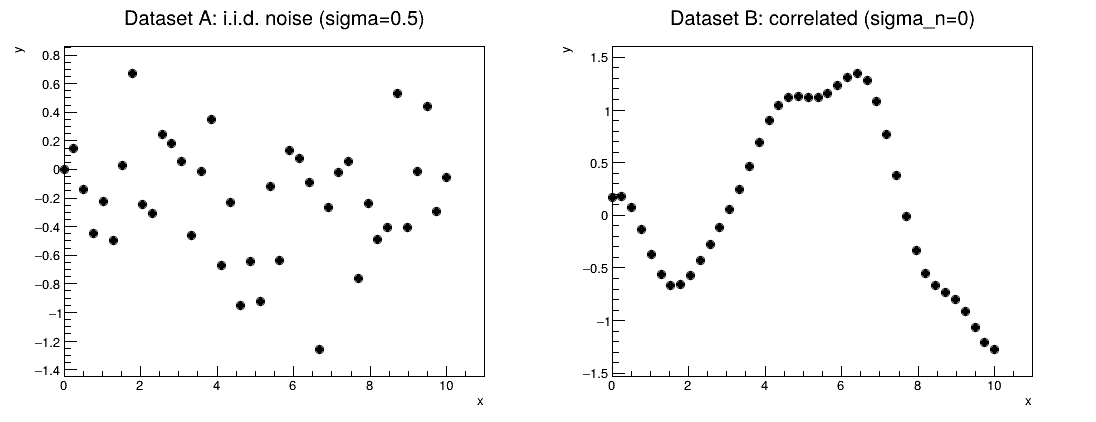

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file gp_toy.png has been created


In [15]:
# kernel (SE/RBF)
def rbf_kernel(x1, x2, sigma_f=1.5, ell=1.2):
    x1 = np.asarray(x1)[:, None]
    x2 = np.asarray(x2)[None, :]
    sqdist = (x1 - x2) ** 2
    return (sigma_f**2) * np.exp(-0.5 * sqdist / (ell**2))

def kernel_fn(a, b):
    return rbf_kernel(a, b, sigma_f=1.5, ell=1.2)

x, y_uncorr, y_corr, c = generate_and_plot_datasets(
    sigma_iid=0.5,
    kernel_fn=kernel_fn,
    sigma_corr_noise=0
)